# 多项式插值：节点选择与逼近误差

在区间 $[-1,1]$ 上逼近 Runge 函数

$$f(x)=\frac{1}{1+25x^2}.$$

使用 SciPy 的 BarycentricInterpolator，比较等距节点与 Chebyshev 节点。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from figure_settings import configure_matplotlib
configure_matplotlib()
from scipy.interpolate import BarycentricInterpolator

def runge(x):
    return 1.0 / (1.0 + 25.0 * x**2)

def equidistant_nodes(degree):
    return np.linspace(-1.0, 1.0, degree + 1)

def chebyshev_nodes(degree):
    k = np.arange(degree + 1)
    return np.cos((2 * k + 1) * np.pi / (2 * (degree + 1)))

grid = np.linspace(-1.0, 1.0, 3000)
truth = runge(grid)

In [2]:
degrees = [4, 8, 12, 16]
records = []

for degree in degrees:
    for node_name, node_function in [
        ("Equidistant nodes", equidistant_nodes),
        ("Chebyshev nodes", chebyshev_nodes),
    ]:
        nodes = node_function(degree)
        interpolator = BarycentricInterpolator(nodes, runge(nodes))
        approximation = interpolator(grid)
        maximum_error = np.max(np.abs(approximation - truth))
        records.append((degree, node_name, maximum_error))

print("Degree    Node type                 Maximum absolute error")
for degree, node_name, maximum_error in records:
    print(f"{degree:>4d}    {node_name:<18} {maximum_error:.4e}")

Degree    Node type                 Maximum absolute error
   4    Equidistant nodes  4.3836e-01
   4    Chebyshev nodes    4.0202e-01
   8    Equidistant nodes  1.0452e+00
   8    Chebyshev nodes    1.7084e-01
  12    Equidistant nodes  3.6634e+00
  12    Chebyshev nodes    6.9215e-02
  16    Equidistant nodes  1.4393e+01
  16    Chebyshev nodes    3.2613e-02


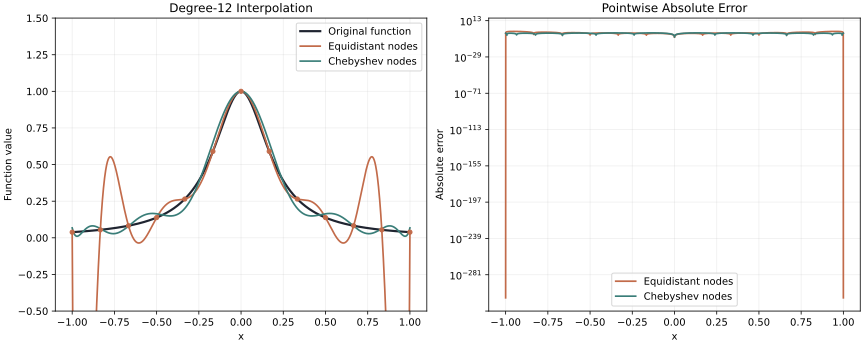

In [3]:
degree = 12
nodes_equal = equidistant_nodes(degree)
nodes_chebyshev = chebyshev_nodes(degree)

polynomial_equal = BarycentricInterpolator(
    nodes_equal,
    runge(nodes_equal),
)(grid)
polynomial_chebyshev = BarycentricInterpolator(
    nodes_chebyshev,
    runge(nodes_chebyshev),
)(grid)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), constrained_layout=True)

axes[0].plot(grid, truth, color="#1f2430", linewidth=2.2, label="Original function")
axes[0].plot(grid, polynomial_equal, color="#c26b4a", linewidth=1.7, label="Equidistant nodes")
axes[0].plot(grid, polynomial_chebyshev, color="#397d78", linewidth=1.7, label="Chebyshev nodes")
axes[0].scatter(nodes_equal, runge(nodes_equal), color="#c26b4a", s=18, zorder=3)
axes[0].set(
    title=f"Degree-{degree} Interpolation",
    xlabel="x",
    ylabel="Function value",
    ylim=(-0.5, 1.5),
)
axes[0].grid(alpha=0.2)
axes[0].legend()

axes[1].semilogy(
    grid,
    np.maximum(np.abs(polynomial_equal - truth), np.finfo(float).tiny),
    color="#c26b4a",
    linewidth=1.7,
    label="Equidistant nodes",
)
axes[1].semilogy(
    grid,
    np.maximum(np.abs(polynomial_chebyshev - truth), np.finfo(float).tiny),
    color="#397d78",
    linewidth=1.7,
    label="Chebyshev nodes",
)
axes[1].set(
    title="Pointwise Absolute Error",
    xlabel="x",
    ylabel="Absolute error",
)
axes[1].grid(True, which="both", alpha=0.2)
axes[1].legend()
plt.show()

## 观察

提高多项式次数并不必然改善全区间逼近。等距节点在区间端点附近可能出现明显振荡；Chebyshev 节点在端点附近更密集，通常能显著降低最大误差。